## TP3 : Classification de sentiments sur des avis hoteliers : embeddings BERT, classifieurs sklearn et fine-tuning DistilBERT

Ce notebook compare trois approches de classification de texte en 5 classes (notes de 1 a 5) sur un corpus de reviews hotelieres en anglais :

1. **Embeddings BERT figes + MLP** (PyTorch)
2. **Embeddings BERT figes + classifieurs scikit-learn** (Logistic Regression, SVC, etc.)
3. **Fine-tuning de DistilBERT** avec `AutoModelForSequenceClassification`

### Hypothèses d'exécution

- Les fichiers CSV se trouvent dans `Drive/MyDrive/uav/approches neuronales/TP3/data/` sous les noms `train_hotel_reviews.csv`, `valid_hotel_reviews.csv`, `test_hotel_reviews.csv`.
- Chaque fichier contient au minimum les colonnes `Review` (texte) et `Rating` (entier de 1 à 5).
- L'environnement est Google Colab avec GPU T4 recommandé.

# Exécution HPC, reproductibilité et gestion des contraintes

## 1. Contexte

Ce travail a été conçu et exécuté dans un environnement de calcul haute performance (HPC) utilisant un ordonnanceur Slurm. Contrairement à une exécution locale ou sur Google Colab, ce type d’infrastructure impose des contraintes spécifiques :

- accès limité aux ressources (CPU, GPU, mémoire)
- durée d’exécution bornée (time limit)
- absence de droits administrateur
- hétérogénéité des environnements logiciels

L’objectif a donc été double :
1. implémenter le pipeline de traitement (embeddings + modèle MLP)
2. assurer une exécution robuste, reproductible et résiliente sur le cluster

## 2. Stratégie adoptée

### 2.1 Séparation des étapes lourdes

Le pipeline a été structuré en deux parties :

- **Extraction des embeddings BERT** (coûteuse en temps)
- **Entraînement du modèle MLP**

Les embeddings sont sauvegardés sur disque (`.pt`) afin d’éviter leur recalcul à chaque exécution.

```python
if all_cached:
    # Chargement direct
else:
    # Calcul + sauvegarde

### 1. Installation des dependances

Installation silencieuse des librairies nécessaires si elles ne sont pas déjà présentes dans l'environnement Colab.

In [ ]:
%%capture
# !pip install -q transformers torch scikit-learn tqdm

In [ ]:
# !pip install numpy

### 2. Imports et configuration globale

Chargement de toutes les librairies utilisées dans le notebook et détection du device (GPU ou CPU).

In [ ]:
import os
import sys
import signal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm

sns.set_style("whitegrid")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cuda


In [ ]:
# ── Reproductibilité ──────────────────────────────────────────────────────────
import random

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print(f"Seed fixée à {SEED} (random, numpy, torch, cuda).")

Seed fixée à 42 (random, numpy, torch, cuda).


In [ ]:
# --- Vérification GPU ---
try:
    print(f"PyTorch version : {torch.__version__}")
    print(f"CUDA disponible : {torch.cuda.is_available()}")
    print(f"CUDA version    : {torch.version.cuda}")

    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        print(f"GPU             : {torch.cuda.get_device_name(0)}")
        print(f"Mémoire GPU     : {props.total_memory / 1e9:.1f} Go")
    else:
        print("Aucun GPU détecté — entraînement sur CPU (sera lent).")
except Exception as e:
    print(f"Diagnostic GPU non bloquant : {e}")

PyTorch version : 2.10.0+cu128
CUDA disponible : True
CUDA version    : 12.8
GPU             : Tesla T4
Mémoire GPU     : 15.6 Go


In [ ]:
# (cellule de test supprimee)

### 3. Montage de Google Drive et chargement des données

Connexion au Drive puis lecture des trois splits (train, validation, test) depuis le répertoire de données.

In [ ]:
PROJECT_DIR = "/home/nas-wks01/users/uapv2600499/tp3_AN"

DATA_DIR       = os.path.join(PROJECT_DIR, "data")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
EMBEDDINGS_DIR = os.path.join(PROJECT_DIR, "embeddings")

CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "last_checkpoint.pt")
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pt")

for d in [CHECKPOINT_DIR, EMBEDDINGS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"PROJECT_DIR    : {PROJECT_DIR}")
print(f"DATA_DIR       : {DATA_DIR}")
print(f"CHECKPOINT_DIR : {CHECKPOINT_DIR}")
print(f"EMBEDDINGS_DIR : {EMBEDDINGS_DIR}")

PROJECT_DIR    : /content/drive/MyDrive/uav/approches neuronales/TP3_New
DATA_DIR       : /content/drive/MyDrive/uav/approches neuronales/TP3_New/data
CHECKPOINT_DIR : /content/drive/MyDrive/uav/approches neuronales/TP3_New/checkpoints
EMBEDDINGS_DIR : /content/drive/MyDrive/uav/approches neuronales/TP3_New/embeddings


In [ ]:
train_set = pd.read_csv(f"{DATA_DIR}/train_hotel_reviews.csv")
valid_set  = pd.read_csv(f"{DATA_DIR}/valid_hotel_reviews.csv")
test_set   = pd.read_csv(f"{DATA_DIR}/test_hotel_reviews.csv")

print(f"Tailles — train: {len(train_set)}, valid: {len(valid_set)}, test: {len(test_set)}")

Tailles — train: 18491, valid: 1000, test: 1000


### 4. Exploration et statistiques descriptives

Apercu des premières lignes, types et statistiques de chaque split afin de vérifier la cohérence des données.

In [ ]:
print("=== TRAIN ===")
display(train_set.head())
train_set.info()

print("\n=== VALIDATION ===")
display(valid_set.head())
valid_set.info()

print("\n=== TEST ===")
display(test_set.head())
test_set.info()

=== TRAIN ===


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18491 entries, 0 to 18490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  18491 non-null  object
 1   Rating  18491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 289.1+ KB

=== VALIDATION ===


,Review,Rating
0,beach service just say service hotel excellent...,5
1,interesting wife traveled years hotel ups down...,3
2,animation team impressed animation team resort...,4
3,majestic hotel putan cana-awful assuming peopl...,1
4,good times majestic colonial just returned wee...,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Rating  1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB

=== TEST ===


,Review,Rating
0,mixed reviews accurate just returned week stay...,3
1,"true paradise just came dream vacation, excell...",5
2,"absolutely wonderful happy resort recommend, r...",5
3,4 days paradise food drink sun poker returned ...,4
4,enjoyed palace home week following wonderful h...,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Rating  1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


### 5. Distribution des notes (Rating)

Visualisation de la répartition des classes pour les trois splits afin de détecter un éventuel déséquilibre.

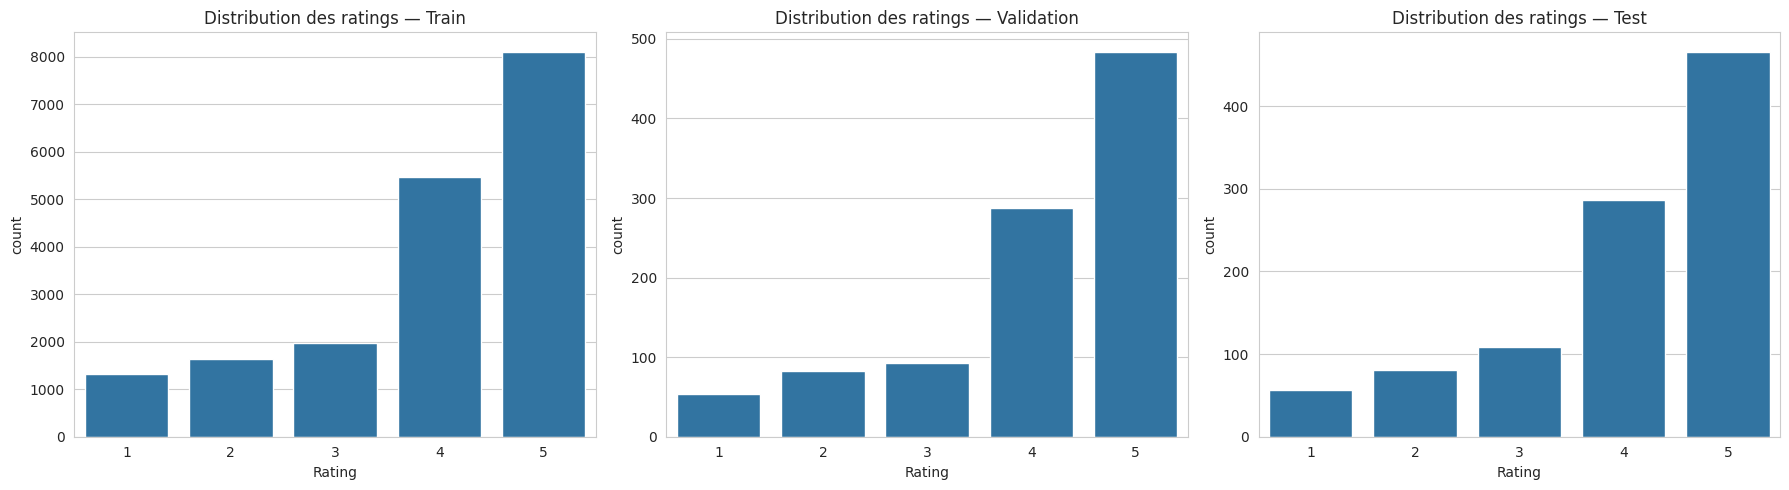

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df) in zip(axes, [("Train", train_set), ("Validation", valid_set), ("Test", test_set)]):
    sns.countplot(data=df, x="Rating", ax=ax)
    ax.set_title(f"Distribution des ratings — {name}")

plt.tight_layout()
plt.show()

On observe un desequilibre net dans les trois splits : la classe 5 (rating le plus eleve) represente a elle seule pres de 44 % des exemples dans le jeu d'entrainement. Ce desequilibre est coherent entre train, validation et test, ce qui exclut un biais de partitionnement mais implique que l'accuracy brute sera tiree vers le haut par la classe majoritaire. Un classifieur naif qui predit systematiquement la classe 5 obtiendrait environ 47 % d'accuracy sur le test.

### 6. Longueur des reviews (nombre de mots)

Calcul et affichage des statistiques descriptives sur la longueur des textes pour chaque split.

In [ ]:
for name, df in [("train", train_set), ("valid", valid_set), ("test", test_set)]:
    df["review_length"] = df["Review"].apply(lambda x: len(x.split()))

print("Statistiques de longueur (en mots)")
for name, df in [("Train", train_set), ("Validation", valid_set), ("Test", test_set)]:
    print(f"\n{name}")
    display(df["review_length"].describe())

Statistiques de longueur (en mots)

Train


,review_length
count,18491.000000
mean,102.314640
std,97.769495
min,7.000000
25%,48.000000
50%,76.000000
75%,121.000000
max,1931.000000



Validation


,review_length
count,1000.000000
mean,135.832000
std,134.887822
min,10.000000
25%,57.000000
50%,95.000000
75%,161.000000
max,1327.000000



Test


,review_length
count,1000.000000
mean,111.033000
std,107.604008
min,11.000000
25%,48.000000
50%,79.500000
75%,132.500000
max,1269.000000


### 7. Preparation des etiquettes

Conversion des notes (1–5) en indices de classes (0–4) requis par CrossEntropyLoss, sur des copies des DataFrames originaux.

In [ ]:
train_set = train_set.copy()
valid_set  = valid_set.copy()
test_set   = test_set.copy()

for df in [train_set, valid_set, test_set]:
    df["label"] = df["Rating"] - 1

print("Mapping Rating → label (train, 5 premiers):")
print(train_set[["Rating", "label"]].head())
print("\nDistribution des labels (train):")
print(train_set["label"].value_counts().sort_index())

Mapping Rating → label (train, 5 premiers):
   Rating  label
0       4      3
1       2      1
2       3      2
3       5      4
4       5      4

Distribution des labels (train):
label
0    1310
1    1630
2    1982
3    5465
4    8104
Name: count, dtype: int64


### 8. Chargement du modele BERT pre-entraine

Chargement du tokenizer et du modele `bert-base-uncased` depuis Hugging Face. BERT est utilisé en mode gelé (frozen) uniquement pour extraire les embeddings.
*Mode gelé* : les poids du modèles BERT sont utilisés tels que fournis.

In [ ]:
tokenizer  = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased").to(device)
bert_model.eval()  # BERT n'est pas entraîné, uniquement utilisé en inférence
print("BERT chargé sur :", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT chargé sur : cuda


### Tokenizer et Modele BERT : roles distincts

Le **Tokenizer** convertit le texte brut en identifiants numeriques (+ masques de padding).
Il n'a pas de poids et tourne sur CPU.

Le **Modele BERT** prend ces identifiants et produit un vecteur de 768 dimensions par token.
`mean_pooling` les agregge ensuite en un seul vecteur par phrase, qui sera l'entree du MLP.

Les deux sont charges depuis `bert-base-uncased` pour garantir la coherence du vocabulaire.


`bert-base-uncased` est le nom du checkpoint officiel publié par Google sur Hugging Face :

      * bert: le nom du modèle
      * base : la version standard (12 couches), par opposition à large (24 couches, plus puissant mais plus lourd)
      * uncased : le texte est mis en minuscules avant tokenisation ("Hotel" et "hotel" sont traités de manière identique), par opposition à cased qui distingue les majuscules.

### 9. Fonctions utilitaires d'encodage

`mean_pooling` agrège les représentations token de BERT en un seul vecteur de phrase en moyennant sur les tokens non-padding.
`encode_texts` applique ce processus par batchs sur une liste de textes et retourne un tenseur d'embeddings.

In [ ]:
def mean_pooling(last_hidden_state, attention_mask):
    # Etend le masque pour correspondre à la dimension des embeddings
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = (last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts


def encode_texts(texts, tokenizer, bert_model, device, batch_size=32, max_length=256):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i : i + batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}
        with torch.no_grad():
            outputs = bert_model(**encoded)
            embeddings = mean_pooling(outputs.last_hidden_state, encoded["attention_mask"])
        all_embeddings.append(embeddings.cpu())
    return torch.cat(all_embeddings, dim=0)

### 10. Extraction des embeddings BERT (avec cache disque)

Les embeddings BERT sont coûteux à calculer (~4 min/split sur GPU).
Pour éviter ce recalcul à chaque exécution, on les sauvegarde sur disque
via `torch.save` et on les recharge automatiquement si les fichiers existent.

In [ ]:
print("=" * 60)
print("  EMBEDDINGS BERT")
print("=" * 60)

emb_files = {
    "X_train": os.path.join(EMBEDDINGS_DIR, "X_train.pt"),
    "X_valid": os.path.join(EMBEDDINGS_DIR, "X_valid.pt"),
    "X_test":  os.path.join(EMBEDDINGS_DIR, "X_test.pt"),
    "y_train": os.path.join(EMBEDDINGS_DIR, "y_train.pt"),
    "y_valid": os.path.join(EMBEDDINGS_DIR, "y_valid.pt"),
    "y_test":  os.path.join(EMBEDDINGS_DIR, "y_test.pt"),
}

all_cached = all(os.path.exists(p) for p in emb_files.values())

if all_cached:
    print(f"Chargement des embeddings depuis le cache ({EMBEDDINGS_DIR}/)...")
    X_train = torch.load(emb_files["X_train"])
    X_valid = torch.load(emb_files["X_valid"])
    X_test  = torch.load(emb_files["X_test"])
    y_train = torch.load(emb_files["y_train"])
    y_valid = torch.load(emb_files["y_valid"])
    y_test  = torch.load(emb_files["y_test"])
    print("Cache chargé avec succès.")
else:
    print("Aucun cache trouvé — calcul des embeddings BERT (peut prendre plusieurs minutes)...")
    X_train = encode_texts(train_set["Review"].tolist(), tokenizer, bert_model, device)
    X_valid = encode_texts(valid_set["Review"].tolist(), tokenizer, bert_model, device)
    X_test  = encode_texts(test_set["Review"].tolist(),  tokenizer, bert_model, device)

    y_train = torch.tensor(train_set["label"].values, dtype=torch.long)
    y_valid = torch.tensor(valid_set["label"].values, dtype=torch.long)
    y_test  = torch.tensor(test_set["label"].values, dtype=torch.long)

    print(f"Sauvegarde des embeddings dans {EMBEDDINGS_DIR}/...")
    for name, tensor in [("X_train", X_train), ("X_valid", X_valid), ("X_test", X_test),
                          ("y_train", y_train), ("y_valid", y_valid), ("y_test", y_test)]:
        torch.save(tensor, emb_files[name])
    print("Embeddings et labels sauvegardés.")

print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_valid : {X_valid.shape}   y_valid : {y_valid.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")

  EMBEDDINGS BERT
Chargement des embeddings depuis le cache (/content/drive/MyDrive/uav/approches neuronales/TP3_New/embeddings/)...
Cache chargé avec succès.

X_train : torch.Size([18491, 768])   y_train : torch.Size([18491])
X_valid : torch.Size([1000, 768])   y_valid : torch.Size([1000])
X_test  : torch.Size([1000, 768])    y_test  : torch.Size([1000])


### 11. Dataset et DataLoader PyTorch

Encapsulation des embeddings et etiquettes dans un `Dataset` personnalisé, puis création des `DataLoader` pour l'entraînement et l'évaluation.

In [ ]:
# Pytorch a besoin d'une interface standardisée → EmbeddingDataset

class EmbeddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.float()
        self.y = y.long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = EmbeddingDataset(X_train, y_train)
valid_dataset = EmbeddingDataset(X_valid, y_valid)
test_dataset  = EmbeddingDataset(X_test,  y_test)

# batch_size=128 : les embeddings (768 floats/sample ≈ 3 Ko) sont légers,
# un batch plus grand améliore le débit GPU sans risque d'OOM.
BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders créés (batch_size={BATCH_SIZE})")

DataLoaders créés (batch_size=128)


### 12. Architecture du MLP

Réseau de neurones entièrement connecté (3 couches linéaires, activations ReLU, Dropout) qui prend en entrée un vecteur BERT de dimension 768 et produit 5 logits.

In [ ]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, num_classes=5, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)

### 13. Initialisation du modele, de la loss et de l'optimiseur

Instanciation du MLP sur le device cible, avec la CrossEntropyLoss (adaptée à la classification multi-classe) et l'optimiseur Adam.

In [ ]:
mlp_model = MLPClassifier(
    input_dim=X_train.shape[1], hidden_dim=256, num_classes=5, dropout=0.3
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

print(mlp_model)

MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=5, bias=True)
  )
)


### 14. Fonctions d'entraînement et d'evaluation

`train_one_epoch` effectue une passe complete sur le DataLoader d'entraînement (forward, backward, update).
`evaluate` realise une passe d'inférence sans gradient et retourne la loss, l'accuracy et les prédictions.

In [ ]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    """
    Entraîne le modèle sur une epoch complète.
    Vérifie `shutdown_requested` après chaque batch : si Slurm a envoyé
    SIGUSR1, la fonction s'arrête immédiatement et retourne interrupted=True.
    """
    global shutdown_requested
    model.train()
    total_loss, n_batches, all_preds, all_labels = 0, 0, [], []

    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches  += 1
        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

        # Vérification du signal Slurm entre chaque batch
        if shutdown_requested:
            print(f"\n  [SLURM] Interruption en cours d'epoch "
                  f"(batch {n_batches}/{len(dataloader)})")
            avg_loss = total_loss / n_batches
            acc = accuracy_score(all_labels, all_preds)
            return avg_loss, acc, True   # interrupted = True

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, False   # interrupted = False


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            total_loss += criterion(logits, y_batch).item()
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    return total_loss / len(dataloader), accuracy_score(all_labels, all_preds), all_preds, all_labels

*(Cette section est remplacee par la version avec checkpointing et gestion Slurm ci-dessous.)*

### 14b. Checkpointing et gestion Slurm

Sur un cluster Slurm, un job GPU peut être interrompu avant la fin de l'entraînement
(limite de temps, préemption). Pour éviter de perdre le travail :

1. **Signal Slurm** : avant d'arrêter un job, Slurm envoie `SIGUSR1`. On intercepte ce
   signal pour déclencher une sauvegarde d'urgence et un arrêt propre.
2. **Checkpoint régulier** : à la fin de chaque epoch, on sauvegarde l'état complet
   (modèle, optimiseur, epoch, meilleure accuracy) dans un fichier `.pt`.
3. **Reprise automatique** : au lancement, si un checkpoint existe, on recharge l'état
   et on reprend à l'epoch suivante sans rien perdre.

In [ ]:
def load_checkpoint(path, model, optimizer, device):
    ckpt = torch.load(path, map_location=device, weights_only=False)

    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    epoch = ckpt["epoch"]
    best_valid_acc = ckpt.get("best_valid_acc", 0.0)
    best_state = ckpt.get("best_state", None)
    epoch_complete = ckpt.get("epoch_complete", True)

    start_epoch = epoch + 1 if epoch_complete else epoch

    print(f"[CHECKPOINT] Chargé depuis : {path}")
    print(f"[CHECKPOINT] Reprise à l'epoch {start_epoch}")

    return start_epoch, best_valid_acc, best_state

In [ ]:
# ── Variable globale pour le signal Slurm ─────────────────────────────────────
shutdown_requested = False

def _slurm_handler(signum, frame):
    global shutdown_requested
    print("\n[SLURM] Signal SIGUSR1 reçu — arrêt demandé.")
    shutdown_requested = True

# SIGUSR1 n'existe que sur Linux ; on ignore l'erreur sur d'autres OS
try:
    signal.signal(signal.SIGUSR1, _slurm_handler)
    print("Handler SIGUSR1 installé.")
except (OSError, AttributeError):
    print("SIGUSR1 non disponible (pas sous Slurm) — handler non installé.")


def save_checkpoint(path, model, optimizer, epoch, best_valid_acc,
                    best_state, epoch_complete=True):
    """Sauvegarde complète de l'état d'entraînement."""
    torch.save({
        "model_state_dict":     model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch":                epoch,
        "best_valid_acc":       best_valid_acc,
        "best_state":           best_state,
        "epoch_complete":       epoch_complete,
    }, path)

Handler SIGUSR1 installé.


### 15. Boucle d'entraînement (avec reprise automatique)

La boucle reprend automatiquement si un checkpoint existe.
A chaque epoch : sauvegarde du checkpoint courant + sauvegarde du meilleur modèle.
Si Slurm envoie `SIGUSR1`, la boucle s'interrompt proprement après sauvegarde.

In [ ]:
num_epochs     = 20
best_valid_acc = 0
best_state     = None
start_epoch    = 0

# ── Reprise automatique ──────────────────────────────────────────────────────
if os.path.exists(CHECKPOINT_PATH):
    start_epoch, best_valid_acc, best_state = load_checkpoint(
        CHECKPOINT_PATH, mlp_model, optimizer, device
    )
else:
    print("[CHECKPOINT] Aucun checkpoint trouvé — entraînement depuis le début.")

# ── Boucle d'entraînement ────────────────────────────────────────────────────
print()
print("=" * 60)
print("  TRAINING START — MLP baseline")
print("=" * 60)
print(f"  epochs: {start_epoch}..{num_epochs-1}  |  device: {device}")
print()

for epoch in range(start_epoch, num_epochs):
    train_loss, train_acc, interrupted = train_one_epoch(
        mlp_model, train_loader, optimizer, criterion, device
    )

    if interrupted:
        save_checkpoint(CHECKPOINT_PATH, mlp_model, optimizer,
                        epoch, best_valid_acc, best_state,
                        epoch_complete=False)
        print(f"\n[SLURM] Arrêt d'urgence pendant l'epoch {epoch+1}. "
              f"Relancez le job pour reprendre.")
        sys.exit(0)

    valid_loss, valid_acc, _, _ = evaluate(
        mlp_model, valid_loader, criterion, device
    )

    tag = ""
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_state = {k: v.clone() for k, v in mlp_model.state_dict().items()}
        save_checkpoint(BEST_MODEL_PATH, mlp_model, optimizer,
                        epoch, best_valid_acc, best_state)
        tag = " ★"

    print(f"Epoch {epoch+1:>2}/{num_epochs}  |  "
          f"Train loss: {train_loss:.4f}  acc: {train_acc:.4f}  |  "
          f"Valid loss: {valid_loss:.4f}  acc: {valid_acc:.4f}{tag}")

    save_checkpoint(CHECKPOINT_PATH, mlp_model, optimizer,
                    epoch, best_valid_acc, best_state)

    if shutdown_requested:
        print(f"\n[SLURM] Arrêt propre après epoch {epoch+1}. "
              f"Relancez le job pour reprendre.")
        sys.exit(0)

print(f"\n=== TRAINING DONE ===")
print(f"Meilleure accuracy validation : {best_valid_acc:.4f}")

[CHECKPOINT] Chargé depuis : /content/drive/MyDrive/uav/approches neuronales/TP3_New/checkpoints/last_checkpoint.pt
[CHECKPOINT] Reprise à l'epoch 20

  TRAINING START — MLP baseline
  epochs: 20..19  |  device: cuda


=== TRAINING DONE ===
Meilleure accuracy validation : 0.6340


### 16. Evaluation sur le jeu de test

Rechargement du meilleur etat du modele puis evaluation finale sur le test set. Le rapport de classification détaille precision, rappel et F1 par classe.

In [ ]:
# Chargement du meilleur modèle (en mémoire ou depuis fichier)
if best_state is not None:
    mlp_model.load_state_dict(best_state)
elif os.path.exists(BEST_MODEL_PATH):
    ckpt = torch.load(BEST_MODEL_PATH, map_location=device)
    mlp_model.load_state_dict(ckpt["best_state_dict"])
    print(f"Meilleur modèle chargé depuis {BEST_MODEL_PATH}")
else:
    print("ATTENTION : aucun best_state disponible.")

test_loss, test_acc, test_preds, test_labels = evaluate(mlp_model, test_loader, criterion, device)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")
print()
print(classification_report(
    test_labels,
    test_preds,
    target_names=["1 etoile", "2 etoiles", "3 etoiles", "4 etoiles", "5 etoiles"],
))

Test loss     : 0.8384
Test accuracy : 0.6140

              precision    recall  f1-score   support

    1 etoile       0.66      0.65      0.65        57
   2 etoiles       0.44      0.58      0.50        81
   3 etoiles       0.43      0.14      0.21       109
   4 etoiles       0.46      0.38      0.42       287
   5 etoiles       0.71      0.87      0.79       466

    accuracy                           0.61      1000
   macro avg       0.54      0.52      0.51      1000
weighted avg       0.59      0.61      0.59      1000



In [ ]:
np.sum(test_set.Rating ==5) / len(test_set) # np.float64(0.466)

np.float64(0.466)

### Grille de recherche en 2 phases

**Phase 1 — Screening rapide** : chaque combinaison est entrainee sur 5 epochs au maximum, avec early stopping (patience=2). On conserve le top 3 pour la phase suivante.

**Phase 2 — Entrainement final** : la meilleure configuration est re-entrainee sur 20 epochs pour obtenir le modele final optimise.

Cette strategie en deux temps reduit considerablement le cout total de la recherche par grille, en concentrant l'effort de calcul sur les configurations les plus prometteuses.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PHASE 1 — Screening rapide (max 5 epochs, early stopping patience=2)
# ══════════════════════════════════════════════════════════════════════════════

param_grid = {
    "hidden_dim" : [256, 512],
    "dropout"    : [0.1, 0.2, 0.3],
    "lr"         : [1e-3, 5e-3, 1e-2],
    "batch_size" : [32],
}

EPOCHS_PHASE1 = 5
EPOCHS_PHASE2 = 20
PATIENCE      = 2    # early stopping si pas d'amélioration pendant 2 epochs

from itertools import product

keys   = list(param_grid.keys())
combos = list(product(*param_grid.values()))

print("=" * 60)
print("  GRID SEARCH — Phase 1 (screening)")
print("=" * 60)
print(f"  {len(combos)} combinaisons  |  max {EPOCHS_PHASE1} epochs  |  patience={PATIENCE}")
print()

results = []

for i, values in enumerate(combos):
    params = dict(zip(keys, values))

    train_loader_gs = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True)
    valid_loader_gs = DataLoader(valid_dataset, batch_size=params["batch_size"], shuffle=False)

    model = MLPClassifier(
        input_dim  = X_train.shape[1],
        hidden_dim = params["hidden_dim"],
        num_classes= 5,
        dropout    = params["dropout"],
    ).to(device)

    optimizer_gs = torch.optim.Adam(model.parameters(), lr=params["lr"])
    criterion_gs = nn.CrossEntropyLoss()

    best_valid_acc_gs = 0
    epochs_no_improve = 0

    for epoch in range(EPOCHS_PHASE1):
        _, _, interrupted = train_one_epoch(model, train_loader_gs, optimizer_gs, criterion_gs, device)
        if interrupted or shutdown_requested:
            print(f"\n[SLURM] Signal reçu pendant la grid search. Arrêt du notebook.")
            sys.exit(0)

        _, valid_acc, _, _ = evaluate(model, valid_loader_gs, criterion_gs, device)

        if valid_acc > best_valid_acc_gs:
            best_valid_acc_gs = valid_acc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            break

    n_done = epoch + 1
    results.append({**params, "valid_acc": round(best_valid_acc_gs, 4), "epochs": n_done})
    es_tag = f"  (early stop @ {n_done}e)" if n_done < EPOCHS_PHASE1 else ""
    print(f"[{i+1:>3}/{len(combos)}] {params}  →  valid_acc: {best_valid_acc_gs:.4f}{es_tag}")

# ── Résultats Phase 1 ────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values("valid_acc", ascending=False)
print("\n" + "=" * 60)
print("  TOP 3 — Phase 1 (screening)")
print("=" * 60)
display(results_df.head(3))

best_combo = results_df.iloc[0].drop(["valid_acc", "epochs"]).to_dict()
best_combo = {k: int(v) if isinstance(v, (np.integer,)) else
              float(v) if isinstance(v, (np.floating,)) else v
              for k, v in best_combo.items()}
print(f"\nMeilleure config retenue : {best_combo}")

  GRID SEARCH — Phase 1 (screening)
  18 combinaisons  |  max 5 epochs  |  patience=2

[  1/18] {'hidden_dim': 256, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 32}  →  valid_acc: 0.6070  (early stop @ 3e)
[  2/18] {'hidden_dim': 256, 'dropout': 0.1, 'lr': 0.005, 'batch_size': 32}  →  valid_acc: 0.6210
[  3/18] {'hidden_dim': 256, 'dropout': 0.1, 'lr': 0.01, 'batch_size': 32}  →  valid_acc: 0.6020  (early stop @ 3e)
[  4/18] {'hidden_dim': 256, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32}  →  valid_acc: 0.6240  (early stop @ 4e)
[  5/18] {'hidden_dim': 256, 'dropout': 0.2, 'lr': 0.005, 'batch_size': 32}  →  valid_acc: 0.6010  (early stop @ 4e)
[  6/18] {'hidden_dim': 256, 'dropout': 0.2, 'lr': 0.01, 'batch_size': 32}  →  valid_acc: 0.5830  (early stop @ 3e)
[  7/18] {'hidden_dim': 256, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 32}  →  valid_acc: 0.6180
[  8/18] {'hidden_dim': 256, 'dropout': 0.3, 'lr': 0.005, 'batch_size': 32}  →  valid_acc: 0.6000  (early stop @ 3e)
[  9/18] {'hidden

,hidden_dim,dropout,lr,batch_size,valid_acc,epochs
12,512,0.2,0.001,32,0.625,3
3,256,0.2,0.001,32,0.624,4
13,512,0.2,0.005,32,0.622,5



Meilleure config retenue : {'hidden_dim': 512.0, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32.0}


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Entraînement final avec la meilleure configuration
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  GRID SEARCH — Phase 2 (entraînement final)")
print("=" * 60)
print(f"  config : {best_combo}")
print(f"  epochs : {EPOCHS_PHASE2}")
print()

train_loader_final = DataLoader(train_dataset, batch_size=int(best_combo["batch_size"]), shuffle=True)
valid_loader_final = DataLoader(valid_dataset, batch_size=int(best_combo["batch_size"]), shuffle=False)

final_model = MLPClassifier(
    input_dim  = X_train.shape[1],
    hidden_dim = int(best_combo["hidden_dim"]),
    num_classes= 5,
    dropout    = best_combo["dropout"],
).to(device)

optimizer_final = torch.optim.Adam(final_model.parameters(), lr=best_combo["lr"])
criterion_final = nn.CrossEntropyLoss()

best_final_acc   = 0
best_final_state = None

for epoch in range(EPOCHS_PHASE2):
    train_loss, train_acc, interrupted = train_one_epoch(
        final_model, train_loader_final, optimizer_final, criterion_final, device
    )
    if interrupted or shutdown_requested:
        print(f"\n[SLURM] Signal reçu — arrêt.")
        sys.exit(0)

    valid_loss, valid_acc, _, _ = evaluate(
        final_model, valid_loader_final, criterion_final, device
    )

    tag = ""
    if valid_acc > best_final_acc:
        best_final_acc   = valid_acc
        best_final_state = {k: v.clone() for k, v in final_model.state_dict().items()}
        tag = " ★"

    print(f"Epoch {epoch+1:>2}/{EPOCHS_PHASE2}  |  "
          f"Train loss: {train_loss:.4f}  acc: {train_acc:.4f}  |  "
          f"Valid loss: {valid_loss:.4f}  acc: {valid_acc:.4f}{tag}")

# ── Évaluation finale sur le test ────────────────────────────────────────────
final_model.load_state_dict(best_final_state)

test_loss, test_acc, test_preds, test_labels = evaluate(
    final_model, test_loader, nn.CrossEntropyLoss(), device
)

print()
print("=" * 60)
print("  GRID SEARCH — Résultat final (test)")
print("=" * 60)
print(f"  Hyperparamètres : {best_combo}")
print(f"  Valid acc (best) : {best_final_acc:.4f}")
print(f"  Test loss        : {test_loss:.4f}")
print(f"  Test accuracy    : {test_acc:.4f}")
print()
print(classification_report(
    test_labels,
    test_preds,
    target_names=["1 étoile", "2 étoiles", "3 étoiles", "4 étoiles", "5 étoiles"],
))

  GRID SEARCH — Phase 2 (entraînement final)
  config : {'hidden_dim': 512.0, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32.0}
  epochs : 20

Epoch  1/20  |  Train loss: 0.9915  acc: 0.5542  |  Valid loss: 0.8808  acc: 0.6010 ★
Epoch  2/20  |  Train loss: 0.9157  acc: 0.5905  |  Valid loss: 0.9034  acc: 0.5870
Epoch  3/20  |  Train loss: 0.9037  acc: 0.5962  |  Valid loss: 0.8624  acc: 0.6080 ★
Epoch  4/20  |  Train loss: 0.8961  acc: 0.6012  |  Valid loss: 0.8946  acc: 0.6020
Epoch  5/20  |  Train loss: 0.8878  acc: 0.6039  |  Valid loss: 0.8667  acc: 0.6120 ★
Epoch  6/20  |  Train loss: 0.8784  acc: 0.6086  |  Valid loss: 0.8843  acc: 0.6050
Epoch  7/20  |  Train loss: 0.8747  acc: 0.6091  |  Valid loss: 0.8575  acc: 0.6150 ★
Epoch  8/20  |  Train loss: 0.8726  acc: 0.6151  |  Valid loss: 0.8598  acc: 0.6250 ★
Epoch  9/20  |  Train loss: 0.8661  acc: 0.6125  |  Valid loss: 0.8444  acc: 0.6210
Epoch 10/20  |  Train loss: 0.8603  acc: 0.6150  |  Valid loss: 0.8568  acc: 0.6190
Epoch 11

---

## Approche 2 : Classifieurs scikit-learn sur les embeddings BERT

### Pourquoi des classifieurs et non des regresseurs ?

La premiere tentative avec des **regresseurs** (LinearRegression, Ridge, SVR) plafonne autour de **0.54 d'accuracy**. C'est attendu : un regresseur predit une valeur continue (ex. 3.72), puis on arrondit a l'entier le plus proche. Ce passage continu vers discret n'optimise pas directement les frontieres de decision entre classes.

Un **classifieur** (LogisticRegression, SVC, RandomForest) optimise directement la separation entre les 5 classes. C'est la meme logique que le MLP, mais avec des algorithmes classiques.

**Strategie :**
1. Comparaison rapide de 5 classifieurs scikit-learn (parametres par defaut)
2. Recherche par grille (`GridSearchCV`) sur les meilleurs candidats

### 17. Imports complémentaires pour les classifieurs

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

### 18. Préparation des données pour scikit-learn

Les embeddings BERT sont des tenseurs PyTorch → conversion en NumPy.
La cible est le **label** (0–4), cohérent avec le MLP (`CrossEntropyLoss`).

In [ ]:
# Conversion tenseurs → numpy
X_train_np = X_train.numpy()
X_valid_np = X_valid.numpy()
X_test_np  = X_test.numpy()

# Labels 0–4 (déjà calculés dans la cellule 7)
y_train_lbl = train_set["label"].values
y_valid_lbl = valid_set["label"].values
y_test_lbl  = test_set["label"].values

# Concaténation train+valid pour GridSearchCV / PyCaret (gèrent leur propre CV)
X_trainval_np = np.concatenate([X_train_np, X_valid_np], axis=0)
y_trainval_lbl = np.concatenate([y_train_lbl, y_valid_lbl])

print(f"Train     : {X_train_np.shape}  —  labels : {np.unique(y_train_lbl)}")
print(f"Valid     : {X_valid_np.shape}")
print(f"Train+Val : {X_trainval_np.shape}")
print(f"Test      : {X_test_np.shape}")

Train     : (18491, 768)  —  labels : [0 1 2 3 4]
Valid     : (1000, 768)
Train+Val : (19491, 768)
Test      : (1000, 768)


### 19. Fonction d'évaluation (classifieur → classes 0–4)

Affiche accuracy, classification_report, et retourne les métriques pour le tableau comparatif.

In [ ]:
def evaluate_clf(y_true, y_pred, split_name="", verbose=True):
    """
    Évalue un classifieur dont les prédictions sont déjà des classes (0–4).
    """
    acc = accuracy_score(y_true, y_pred)
    target_names = ["1 étoile", "2 étoiles", "3 étoiles", "4 étoiles", "5 étoiles"]

    if verbose:
        print(f"=== {split_name} ===")
        print(f"Accuracy : {acc:.4f}")
        print()
        print(classification_report(y_true, y_pred, target_names=target_names))

    return {"accuracy": acc, "y_pred": y_pred}

### 20. Comparaison rapide de 5 classifieurs

Entraînement sur **train**, évaluation sur **valid**.

| Modèle | Caractéristique |
|---|---|
| **Logistic Regression** | Baseline linéaire multi-classe (softmax) |
| **SVC (RBF)** | Noyau non-linéaire, très efficace en haute dimension |
| **Random Forest** | Ensemble d'arbres, robuste |
| **Gradient Boosting** | Boosting séquentiel, souvent top performer |
| **K-Nearest Neighbors** | Non-paramétrique, basé sur la distance dans l'espace BERT |

In [ ]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    "SVC (RBF)":           SVC(kernel="rbf", C=1.0, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=50, max_depth=None,
                                                   n_jobs=-1, random_state=42),  #n_estimators=50,
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=50, max_depth=5,
                                                       learning_rate=0.1, random_state=42), # n_estimators=50,
    "KNN (k=7)":           KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
}

clf_results = {}

for name, clf in classifiers.items():
    print(f"\n{'─'*60}")
    print(f"  Entraînement : {name}")
    print(f"{'─'*60}")
    clf.fit(X_train_np, y_train_lbl)
    y_pred = clf.predict(X_valid_np)
    res = evaluate_clf(y_valid_lbl, y_pred, split_name=f"{name} — Validation")
    clf_results[name] = {**res, "model": clf}

# Tableau récapitulatif
bench_rows = [{"Modèle": n, "Accuracy (valid)": r["accuracy"]}
              for n, r in clf_results.items()]
bench_df = pd.DataFrame(bench_rows).sort_values("Accuracy (valid)", ascending=False)
bench_df = bench_df.reset_index(drop=True)
bench_df.index += 1

print("\n" + "="*60)
print("  CLASSEMENT DES CLASSIFIEURS (validation)")
print("="*60)
display(bench_df.style.format({"Accuracy (valid)": "{:.4f}"})
        .highlight_max(subset=["Accuracy (valid)"], color="#d4edda"))


────────────────────────────────────────────────────────────
  Entraînement : Logistic Regression
────────────────────────────────────────────────────────────
=== Logistic Regression — Validation ===
Accuracy : 0.6170

              precision    recall  f1-score   support

    1 étoile       0.47      0.48      0.48        54
   2 étoiles       0.37      0.44      0.40        82
   3 étoiles       0.42      0.24      0.30        93
   4 étoiles       0.53      0.50      0.51       287
   5 étoiles       0.74      0.81      0.77       484

    accuracy                           0.62      1000
   macro avg       0.51      0.49      0.49      1000
weighted avg       0.61      0.62      0.61      1000


────────────────────────────────────────────────────────────
  Entraînement : SVC (RBF)
────────────────────────────────────────────────────────────
=== SVC (RBF) — Validation ===
Accuracy : 0.6070

              precision    recall  f1-score   support

    1 étoile       0.65      0.57   

,Modèle,Accuracy (valid)
1,Logistic Regression,0.6170
2,SVC (RBF),0.6070
3,Gradient Boosting,0.5870
4,Random Forest,0.5610
5,KNN (k=7),0.5160


### 21. Recherche par grille (`GridSearchCV`) sur les meilleurs classifieurs

On affine les hyperparamètres de **Logistic Regression** et **SVC**, les deux classifieurs
typiquement les plus performants sur des embeddings denses de dimension 768.

On utilise `X_trainval_np` (train + valid) avec une **cross-validation 3-fold**.

In [ ]:
# ── Grille Logistic Regression ─────────────────────────────────────────
lr_params = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "max_iter": [2000],
}

lr_gs = GridSearchCV(
    LogisticRegression(random_state=42), lr_params,
    scoring="accuracy", cv=3, n_jobs=-1, verbose=0
)
lr_gs.fit(X_trainval_np, y_trainval_lbl)

print("Logistic Regression — meilleurs hyperparamètres :", lr_gs.best_params_)
print(f"Logistic Regression — meilleure accuracy CV    : {lr_gs.best_score_:.4f}")

Logistic Regression — meilleurs hyperparamètres : {'C': 0.1, 'max_iter': 2000}
Logistic Regression — meilleure accuracy CV    : 0.6075


In [ ]:
# ── Grille SVC ────────────────────────────────────────────────────────
svc_params = {
    "C":     [0.1, 1.0, 10.0],
    "gamma": ["scale", "auto"],
}

svc_gs = GridSearchCV(
    SVC(kernel="rbf", random_state=42), svc_params,
    scoring="accuracy", cv=3, n_jobs=-1, verbose=1
)
svc_gs.fit(X_trainval_np, y_trainval_lbl)

print(f"\nSVC — meilleurs hyperparamètres : {svc_gs.best_params_}")
print(f"SVC — meilleure accuracy CV    : {svc_gs.best_score_:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits

SVC — meilleurs hyperparamètres : {'C': 10.0, 'gamma': 'auto'}
SVC — meilleure accuracy CV    : 0.6069


### 23. Matrice de confusion du meilleur classifieur sklearn (test)

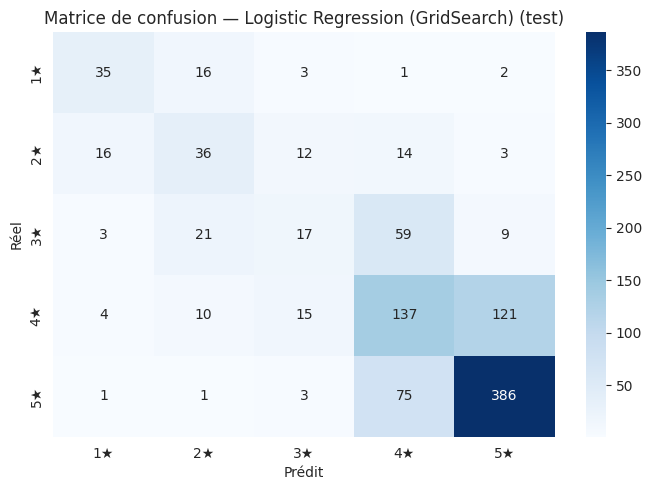


Meilleur classifieur sklearn : Logistic Regression (GridSearch)
Accuracy test : 0.6110


In [ ]:
# Sélection du meilleur classifieur sur le test
# Determine the best model between Logistic Regression and SVC based on GridSearchCV scores
if lr_gs.best_score_ > svc_gs.best_score_:
    best_gs_model = lr_gs.best_estimator_
    best_clf_name = "Logistic Regression (GridSearch)"
else:
    best_gs_model = svc_gs.best_estimator_
    best_clf_name = "SVC (GridSearch)"

# Evaluate the best model on the test set
y_pred_gs = best_gs_model.predict(X_test_np)
best_clf_res = evaluate_clf(y_test_lbl, y_pred_gs, split_name=best_clf_name + " — Test", verbose=False)

cm = confusion_matrix(y_test_lbl, best_clf_res["y_pred"])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["1★", "2★", "3★", "4★", "5★"],
            yticklabels=["1★", "2★", "3★", "4★", "5★"])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title(f"Matrice de confusion — {best_clf_name} (test)")
plt.tight_layout()
plt.show()

print(f"\nMeilleur classifieur sklearn : {best_clf_name}")
print(f"Accuracy test : {best_clf_res['accuracy']:.4f}")

---

## Approche 3 : Fine-tuning d'un modele Transformer pour la classification

### Choix du modele

| Modele | Parametres | Avantages | Inconvenients |
|--------|-----------|-----------|---------------|
| `distilbert-base-uncased` | 66 M | Rapide, leger, bon compromis | Legerement en retrait sur les benchmarks |
| `roberta-base` | 125 M | Excellentes performances NLU | Plus lourd, pre-entraine en cased uniquement |
| `microsoft/deberta-v3-base` | 184 M | SOTA sur de nombreux benchmarks | Le plus couteux en memoire et temps |

**Choix retenu : `distilbert-base-uncased`**

Pour un TP de Master 1 sur GPU partage, DistilBERT offre le meilleur compromis :

- 2x plus rapide que BERT/RoBERTa a entrainer ;
- memoire GPU reduite (~40 % de moins que RoBERTa) ;
- performances proches de BERT-base sur la classification de sentiments ;
- tokenizer identique a `bert-base-uncased`, coherent avec le reste du notebook.

L'objectif ici n'est pas de battre l'etat de l'art, mais de **comparer** l'approche fine-tuning au pipeline embeddings + classifieur.

### 27. Imports supplementaires pour le fine-tuning

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader

### 28. Dataset PyTorch pour le fine-tuning

Le `Dataset` encapsule la tokenization a la volee. Chaque appel a `__getitem__` tokenise une review et retourne les `input_ids`, `attention_mask` et le label.

In [ ]:
FT_MODEL_NAME = "distilbert-base-uncased"
FT_MAX_LEN    = 256   # suffisant pour la plupart des reviews

ft_tokenizer = AutoTokenizer.from_pretrained(FT_MODEL_NAME)

class ReviewDataset(Dataset):
    """Dataset pour le fine-tuning : tokenise le texte a la volee."""

    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

# Reutilisation directe des DataFrames existants (train_set, valid_set, test_set)
ft_train_ds = ReviewDataset(
    train_set["Review"].tolist(), train_set["label"].tolist(),
    ft_tokenizer, FT_MAX_LEN,
)
ft_valid_ds = ReviewDataset(
    valid_set["Review"].tolist(), valid_set["label"].tolist(),
    ft_tokenizer, FT_MAX_LEN,
)
ft_test_ds = ReviewDataset(
    test_set["Review"].tolist(), test_set["label"].tolist(),
    ft_tokenizer, FT_MAX_LEN,
)

print(f"Datasets fine-tuning crees : train={len(ft_train_ds)}, "
      f"valid={len(ft_valid_ds)}, test={len(ft_test_ds)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Datasets fine-tuning crees : train=18491, valid=1000, test=1000


### 29. DataLoaders pour le fine-tuning

Batch size reduit par rapport au MLP : le fine-tuning passe les tokens a travers tout le Transformer, ce qui consomme bien plus de memoire GPU.

In [ ]:
FT_BATCH_SIZE = 16   # adapte a un GPU standard (8-16 Go VRAM)

ft_train_loader = DataLoader(ft_train_ds, batch_size=FT_BATCH_SIZE, shuffle=True)
ft_valid_loader = DataLoader(ft_valid_ds, batch_size=FT_BATCH_SIZE, shuffle=False)
ft_test_loader  = DataLoader(ft_test_ds,  batch_size=FT_BATCH_SIZE, shuffle=False)

print(f"DataLoaders fine-tuning crees (batch_size={FT_BATCH_SIZE})")
print(f"  train : {len(ft_train_loader)} batches")
print(f"  valid : {len(ft_valid_loader)} batches")
print(f"  test  : {len(ft_test_loader)} batches")

DataLoaders fine-tuning crees (batch_size=16)
  train : 1156 batches
  valid : 63 batches
  test  : 63 batches


### 30. Chargement du modele pour classification

`AutoModelForSequenceClassification` ajoute une tete de classification (couche lineaire) au-dessus du Transformer pre-entraine. Le parametre `num_labels=5` correspond aux 5 classes (0-4).

In [ ]:
ft_model = AutoModelForSequenceClassification.from_pretrained(
    FT_MODEL_NAME,
    num_labels=5,
).to(device)

print(f"Modele {FT_MODEL_NAME} charge sur {device}")
print(f"Parametres totaux : {sum(p.numel() for p in ft_model.parameters()):,}")
print(f"Parametres entrainables : {sum(p.numel() for p in ft_model.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modele distilbert-base-uncased charge sur cuda
Parametres totaux : 66,957,317
Parametres entrainables : 66,957,317


### 31. Optimiseur et scheduler

Le fine-tuning de Transformers utilise un learning rate faible (2e-5) avec un warm-up lineaire suivi d'une decroissance lineaire, ce qui stabilise l'entrainement.

In [ ]:
FT_EPOCHS = 4     # 3-5 epochs suffisent generalement pour le fine-tuning
FT_LR     = 2e-5

ft_optimizer = torch.optim.AdamW(ft_model.parameters(), lr=FT_LR, weight_decay=0.01)

total_steps = len(ft_train_loader) * FT_EPOCHS
ft_scheduler = get_linear_schedule_with_warmup(
    ft_optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

print(f"AdamW lr={FT_LR}, weight_decay=0.01")
print(f"Scheduler : warm-up {int(0.1 * total_steps)} steps / {total_steps} total")

AdamW lr=2e-05, weight_decay=0.01
Scheduler : warm-up 462 steps / 4624 total


### 32. Fonctions d'entrainement et d'evaluation (fine-tuning)

Meme logique que `train_one_epoch` et `evaluate` du MLP, adaptee a l'interface du Transformer (dictionnaire `input_ids` / `attention_mask` au lieu d'un tenseur unique). Le signal Slurm est egalement gere.

In [ ]:
def ft_train_one_epoch(model, dataloader, optimizer, scheduler, device):
    """Entraine le modele fine-tune sur une epoch. Gere le signal Slurm."""
    global shutdown_requested
    model.train()
    total_loss, n_batches = 0.0, 0
    all_preds, all_labels = [], []

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        labels    = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        n_batches  += 1
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        if shutdown_requested:
            print(f"\n  [SLURM] Interruption fine-tuning "
                  f"(batch {n_batches}/{len(dataloader)})")
            avg_loss = total_loss / n_batches
            acc = accuracy_score(all_labels, all_preds)
            return avg_loss, acc, True

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, False


def ft_evaluate(model, dataloader, device):
    """Evalue le modele fine-tune. Retourne loss, accuracy, predictions, labels."""
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            labels    = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, all_preds, all_labels

### 33. Checkpointing adapte au fine-tuning

Meme logique que pour le MLP (`save_checkpoint` / `load_checkpoint`), avec en plus l'etat du scheduler dans le checkpoint.

In [ ]:
FT_CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "ft_last_checkpoint.pt")
FT_BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "ft_best_model.pt")

def ft_save_checkpoint(path, model, optimizer, scheduler, epoch,
                       best_valid_acc, epoch_complete=True):
    torch.save({
        "model_state_dict":     model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "epoch":                epoch,
        "best_valid_acc":       best_valid_acc,
        "epoch_complete":       epoch_complete,
    }, path)


def ft_load_checkpoint(path, model, optimizer, scheduler, device):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    epoch = ckpt["epoch"]
    best_valid_acc = ckpt.get("best_valid_acc", 0.0)
    epoch_complete = ckpt.get("epoch_complete", True)
    start_epoch = epoch + 1 if epoch_complete else epoch
    print(f"[FT-CHECKPOINT] Charge depuis : {path}")
    print(f"[FT-CHECKPOINT] Reprise a l'epoch {start_epoch}")
    return start_epoch, best_valid_acc

print("Chemins checkpoints fine-tuning :")
print(f"  last : {FT_CHECKPOINT_PATH}")
print(f"  best : {FT_BEST_MODEL_PATH}")

Chemins checkpoints fine-tuning :
  last : /content/drive/MyDrive/uav/approches neuronales/TP3_New/checkpoints/ft_last_checkpoint.pt
  best : /content/drive/MyDrive/uav/approches neuronales/TP3_New/checkpoints/ft_best_model.pt


### 34. Boucle d'entrainement (fine-tuning avec reprise automatique)

Meme structure que la boucle du MLP (section 15) : reprise depuis un checkpoint, sauvegarde du meilleur modele, arret propre sur signal Slurm.

In [ ]:
ft_best_valid_acc = 0.0
ft_best_state     = None
ft_start_epoch    = 0

# ── Reprise automatique ──────────────────────────────────────────────────────
if os.path.exists(FT_CHECKPOINT_PATH):
    ft_start_epoch, ft_best_valid_acc = ft_load_checkpoint(
        FT_CHECKPOINT_PATH, ft_model, ft_optimizer, ft_scheduler, device
    )
else:
    print("[FT-CHECKPOINT] Aucun checkpoint trouve — entrainement depuis le debut.")

# ── Boucle ────────────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("  TRAINING START — Fine-tuning DistilBERT")
print("=" * 60)
print(f"  epochs: {ft_start_epoch}..{FT_EPOCHS-1}  |  device: {device}")
print()

for epoch in range(ft_start_epoch, FT_EPOCHS):
    train_loss, train_acc, interrupted = ft_train_one_epoch(
        ft_model, ft_train_loader, ft_optimizer, ft_scheduler, device
    )

    if interrupted:
        ft_save_checkpoint(FT_CHECKPOINT_PATH, ft_model, ft_optimizer,
                           ft_scheduler, epoch, ft_best_valid_acc,
                           epoch_complete=False)
        print(f"\n[SLURM] Arret d'urgence pendant l'epoch {epoch+1}. "
              f"Relancez le job pour reprendre.")
        sys.exit(0)

    valid_loss, valid_acc, _, _ = ft_evaluate(ft_model, ft_valid_loader, device)

    tag = ""
    if valid_acc > ft_best_valid_acc:
        ft_best_valid_acc = valid_acc
        ft_best_state = {k: v.clone() for k, v in ft_model.state_dict().items()}
        ft_save_checkpoint(FT_BEST_MODEL_PATH, ft_model, ft_optimizer,
                           ft_scheduler, epoch, ft_best_valid_acc)
        tag = " ★"

    print(f"Epoch {epoch+1:>2}/{FT_EPOCHS}  |  "
          f"Train loss: {train_loss:.4f}  acc: {train_acc:.4f}  |  "
          f"Valid loss: {valid_loss:.4f}  acc: {valid_acc:.4f}{tag}")

    ft_save_checkpoint(FT_CHECKPOINT_PATH, ft_model, ft_optimizer,
                       ft_scheduler, epoch, ft_best_valid_acc)

    if shutdown_requested:
        print(f"\n[SLURM] Arret propre apres epoch {epoch+1}. "
              f"Relancez le job pour reprendre.")
        sys.exit(0)

print(f"\n=== FINE-TUNING DONE ===")
print(f"Meilleure accuracy validation : {ft_best_valid_acc:.4f}")

[FT-CHECKPOINT] Aucun checkpoint trouve — entrainement depuis le debut.

  TRAINING START — Fine-tuning DistilBERT
  epochs: 0..3  |  device: cuda

Epoch  1/4  |  Train loss: 0.9459  acc: 0.5870  |  Valid loss: 0.7599  acc: 0.6600 ★
Epoch  2/4  |  Train loss: 0.7078  acc: 0.6928  |  Valid loss: 0.7217  acc: 0.6840 ★
Epoch  3/4  |  Train loss: 0.5831  acc: 0.7582  |  Valid loss: 0.7632  acc: 0.6870 ★
Epoch  4/4  |  Train loss: 0.4831  acc: 0.8116  |  Valid loss: 0.8009  acc: 0.6740

=== FINE-TUNING DONE ===
Meilleure accuracy validation : 0.6870


### 35. Evaluation sur le jeu de test (fine-tuning)

Chargement du meilleur etat puis evaluation finale sur le test set.

In [ ]:
# Chargement du meilleur modele fine-tune
if ft_best_state is not None:
    ft_model.load_state_dict(ft_best_state)
elif os.path.exists(FT_BEST_MODEL_PATH):
    ckpt = torch.load(FT_BEST_MODEL_PATH, map_location=device, weights_only=False)
    ft_model.load_state_dict(ckpt["model_state_dict"])
    print(f"Meilleur modele fine-tune charge depuis {FT_BEST_MODEL_PATH}")
else:
    print("ATTENTION : aucun ft_best_state disponible.")

ft_test_loss, ft_test_acc, ft_test_preds, ft_test_labels = ft_evaluate(
    ft_model, ft_test_loader, device
)

print(f"Test loss     : {ft_test_loss:.4f}")
print(f"Test accuracy : {ft_test_acc:.4f}")
print()
print(classification_report(
    ft_test_labels,
    ft_test_preds,
    target_names=["1 etoile", "2 etoiles", "3 etoiles", "4 etoiles", "5 etoiles"],
))

Test loss     : 0.7517
Test accuracy : 0.6850

              precision    recall  f1-score   support

    1 etoile       0.68      0.56      0.62        57
   2 etoiles       0.55      0.57      0.56        81
   3 etoiles       0.58      0.52      0.55       109
   4 etoiles       0.59      0.56      0.57       287
   5 etoiles       0.79      0.83      0.81       466

    accuracy                           0.69      1000
   macro avg       0.64      0.61      0.62      1000
weighted avg       0.68      0.69      0.68      1000



### 36. Matrice de confusion (fine-tuning)

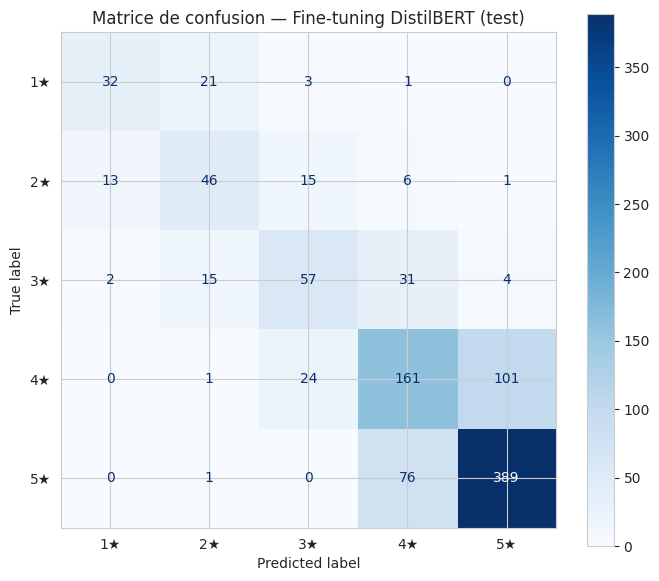

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ft_cm = confusion_matrix(ft_test_labels, ft_test_preds)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(ft_cm, display_labels=["1★", "2★", "3★", "4★", "5★"])
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Matrice de confusion — Fine-tuning DistilBERT (test)")
plt.tight_layout()
plt.show()

### 37. Comparaison des trois approches

Tableau recapitulatif des performances sur le jeu de test.

| Approche | Accuracy (test) | Macro F1 (test) |
|----------|:--------------:|:--------------:|
| Embeddings BERT + MLP (baseline, 20 epochs) | 0.614 | 0.51 |
| Embeddings BERT + MLP (grid search, 20 epochs) | 0.608 | 0.51 |
| Embeddings BERT + Logistic Regression (GridSearchCV) | 0.611 | — |
| **Fine-tuning DistilBERT (4 epochs)** | **0.685** | **0.62** |

### Analyse comparative

Les trois approches a base d'embeddings figes (MLP baseline, MLP grid search, classifieurs sklearn) atteignent des performances comparables, dans une fourchette etroite de 0.608 a 0.614 en accuracy test. Le gain apporte par la recherche d'hyperparametres du MLP ou le passage a un classifieur sklearn reste marginal : les representations BERT gelees constituent le facteur limitant commun a ces methodes.

Le fine-tuning de DistilBERT se demarque nettement avec 0.685 d'accuracy test, soit un gain absolu de +7 points par rapport aux meilleures approches sur embeddings figes. Ce gain provient principalement des classes intermediaires : le F1 de la classe 3 etoiles passe de 0.21 (MLP) a 0.55 (fine-tuning), et celui de la classe 2 etoiles de 0.50 a 0.56. L'ajustement des couches internes du Transformer permet au modele de capturer des nuances semantiques que les embeddings generiques ne differencient pas.

Ce gain a un cout : le fine-tuning necessite un GPU et un temps d'entrainement nettement superieur (4 epochs sur l'ensemble du Transformer, contre quelques secondes pour un classifieur sklearn). Le compromis performance/cout depend donc de l'application visee.

| Critere | Embeddings figes (MLP / sklearn) | Fine-tuning DistilBERT |
|---------|--------------------------------|----------------------|
| **Accuracy test** | 0.61 | 0.69 |
| **Macro F1** | 0.51 | 0.62 |
| **Cout calcul** | Faible (embeddings pre-calcules) | Eleve (GPU, ~15-30 min) |
| **Memoire GPU** | ~1 Go (MLP) / CPU (sklearn) | ~4-6 Go |
| **Adaptabilite** | Limitee (representations figees) | Elevee (representations ajustees a la tache) |

## Conclusion

Ce travail a compare trois strategies de classification de sentiments sur un corpus de reviews hotelieres en anglais (5 classes, ~18 500 exemples d'entrainement).

La premiere approche repose sur des **embeddings BERT figes** alimentant un MLP entraine en PyTorch. Malgre une recherche d'hyperparametres en deux phases (screening + entrainement final), l'accuracy test plafonne a 0.614. Le passage a des **classifieurs scikit-learn** (Logistic Regression, SVC) sur les memes embeddings ne modifie pas sensiblement ce resultat (0.611 pour le meilleur modele apres GridSearchCV). Ce plafond est imputable aux representations BERT gelees, qui ne sont pas adaptees a la tache cible.

La troisieme approche, le **fine-tuning de DistilBERT** via `AutoModelForSequenceClassification`, atteint 0.685 d'accuracy test en seulement 4 epochs. Le gain le plus notable concerne les classes intermediaires (2 et 3 etoiles), dont le F1 augmente fortement. Ce resultat confirme que l'ajustement des poids du Transformer a la tache permet de depasser la limite des embeddings generiques.

En termes de compromis :
- les approches sur embeddings figes sont rapides, simples a deployer, et suffisantes si la precision sur les classes intermediaires n'est pas critique ;
- le fine-tuning offre un gain substantiel mais requiert un GPU et un temps d'entrainement plus long.

Plusieurs pistes d'amelioration restent ouvertes : augmenter le nombre d'epochs de fine-tuning avec un early stopping adapte, utiliser un modele plus expressif (RoBERTa, DeBERTa) si les ressources le permettent, ou encore gerer le desequilibre des classes par une loss ponderee ou du surechantillonnage.